In [159]:
!pip -q install torch torchvision torchaudio
!pip -q install seaborn scikit-learn

In [160]:

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    LabelEncoder
)

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve
)

# Ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

In [161]:


dataset_url = "https://raw.githubusercontent.com/dibakar1612/ANN/refs/heads/main/heart.csv"

df = pd.read_csv(dataset_url)

print("Dataset Loaded Successfully!")
print()

print("Dataset Shape:")
print(df.shape)

print()

df.head()

Dataset Loaded Successfully!

Dataset Shape:
(303, 14)



,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [162]:
# Basic Dataset Information

print("Dataset Information")
print("="*50)

df.info()

print("\n")

print("Missing Values")
print("="*50)

print(df.isnull().sum())

print("\n")

print("Statistical Summary")
print("="*50)

df.describe()

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


Missing Values
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


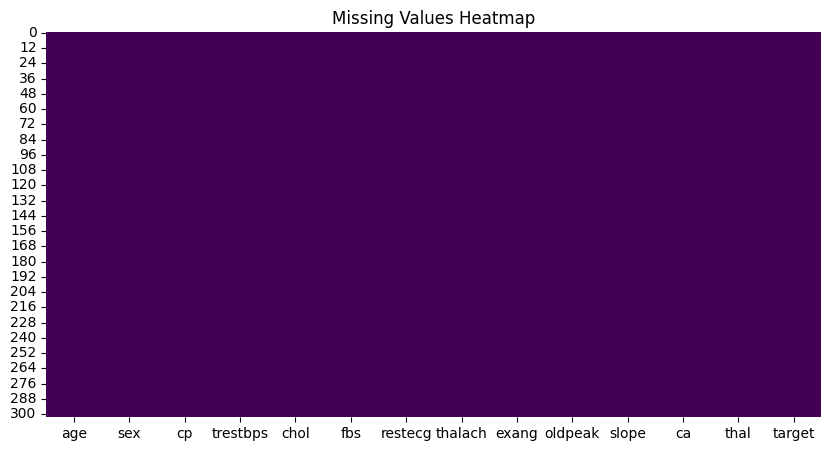

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [163]:
# Missing Value Heatmap

plt.figure(figsize=(10,5))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap="viridis"
)

plt.title("Missing Values Heatmap")

plt.show()
print(df.isnull().sum())

In [164]:
# Split Features and Target

# Assume last column is the target
X = df.iloc[:, :-1]

y = df.iloc[:, -1]

print("Feature Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Shape : (303, 13)
Target Shape : (303,)


In [165]:
# Identify Feature Types

numerical_features = X.select_dtypes(
    include=["int64","float64"]
).columns

categorical_features = X.select_dtypes(
    exclude=["int64","float64"]
).columns

print("Numerical Features")
print(numerical_features)

print()

print("Categorical Features")
print(categorical_features)

Numerical Features
Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal'],
      dtype='object')

Categorical Features
Index([], dtype='object')


In [166]:
# Data Preprocessing Pipeline

numeric_pipeline = Pipeline(

    steps=[

        (
            "imputer",
            SimpleImputer(strategy="median")
        ),

        (
            "scaler",
            StandardScaler()
        )

    ]

)

categorical_pipeline = Pipeline(

    steps=[

        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),

        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )

    ]

)

preprocessor = ColumnTransformer(

    transformers=[

        (
            "numeric",
            numeric_pipeline,
            numerical_features
        ),

        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )

    ]

)

In [167]:
# Apply Preprocessing

X_processed = preprocessor.fit_transform(X)

# Convert sparse matrix to dense array if needed
if hasattr(X_processed, "toarray"):
    X_processed = X_processed.toarray()

print("Processed Feature Shape")

print(X_processed.shape)

Processed Feature Shape
(303, 13)


In [168]:
# Encode Target Variable

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Classes")

print(label_encoder.classes_)

Classes
[0 1]


In [169]:
# Stratified Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(

    X_processed,
    y_encoded,

    test_size=0.20,

    stratify=y_encoded,

    random_state=42

)

print("Training Samples :", len(X_train))
print("Testing Samples :", len(X_test))

Training Samples : 242
Testing Samples : 61


In [170]:
# Split Training Data into Training and Validation Sets

X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    stratify=y_train,
    random_state=42
)

print("Training Samples   :", len(X_train))
print("Validation Samples :", len(X_val))
print("Testing Samples    :", len(X_test))

Training Samples   : 193
Validation Samples : 49
Testing Samples    : 61


In [171]:
# Convert NumPy Arrays to PyTorch Tensors

X_train_tensor = torch.tensor(
    X_train,
    dtype=torch.float32
)

X_val_tensor = torch.tensor(
    X_val,
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test,
    dtype=torch.float32
)

# Binary classification
y_train_tensor = torch.tensor(
    y_train,
    dtype=torch.float32
).view(-1,1)

y_val_tensor = torch.tensor(
    y_val,
    dtype=torch.float32
).view(-1,1)

y_test_tensor = torch.tensor(
    y_test,
    dtype=torch.float32
).view(-1,1)

In [172]:

# Create TensorDataset Objects


train_dataset = TensorDataset(

    X_train_tensor,
    y_train_tensor

)

val_dataset = TensorDataset(

    X_val_tensor,
    y_val_tensor

)

test_dataset = TensorDataset(

    X_test_tensor,
    y_test_tensor
)

print("Datasets Created Successfully!")

Datasets Created Successfully!


In [173]:
# Shallow Neural Network
# Exactly ONE hidden layer

class ShallowNN(nn.Module):

    def __init__(self, input_size, hidden_size, activation):

        super().__init__()

        # Select activation function
        if activation == "relu":
            act = nn.ReLU()

        elif activation == "sigmoid":
            act = nn.Sigmoid()

        else:
            raise ValueError("Activation must be 'relu' or 'sigmoid'")

        self.network = nn.Sequential(

            nn.Linear(input_size, hidden_size),

            act,

            nn.Linear(hidden_size, 1)

        )

    def forward(self, x):
        return self.network(x)

In [174]:
#Train Function
def train_model(model,
                train_loader,
                val_loader,
                criterion,
                optimizer,
                epochs=50):

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    for epoch in range(epochs):

        # Training

        model.train()

        running_loss = 0
        correct = 0
        total = 0

        for X_batch, y_batch in train_loader:

            optimizer.zero_grad()

            outputs = model(X_batch)

            loss = criterion(outputs, y_batch)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

            predictions = (torch.sigmoid(outputs) > 0.5).float()

            correct += (predictions == y_batch).sum().item()

            total += y_batch.size(0)

        train_loss = running_loss / len(train_loader)
        train_acc = correct / total

        # Validation

        model.eval()

        val_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():

            for X_batch, y_batch in val_loader:

                outputs = model(X_batch)

                loss = criterion(outputs, y_batch)

                val_loss += loss.item()

                predictions = (torch.sigmoid(outputs) > 0.5).float()

                correct += (predictions == y_batch).sum().item()

                total += y_batch.size(0)

        val_loss /= len(val_loader)
        val_acc = correct / total

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch {epoch+1:02d}/{epochs} | "
            f"Train Loss {train_loss:.4f} | "
            f"Val Loss {val_loss:.4f} | "
            f"Train Acc {train_acc:.4f} | "
            f"Val Acc {val_acc:.4f}"
        )

    return history

In [175]:
# Hyperparameter Tuning

hidden_units_list = [8, 16, 32, 64]

activation_list = ["relu", "sigmoid"]

batch_size_list = [16, 32, 64]

best_accuracy = 0

best_model = None

best_params = None

best_history = None

In [176]:
# Grid Search

criterion = nn.BCEWithLogitsLoss()

input_size = X_train.shape[1]

for hidden in hidden_units_list:

    for activation in activation_list:

        for batch_size in batch_size_list:

            print("="*60)

            print(f"Hidden={hidden}")

            print(f"Activation={activation}")

            print(f"Batch Size={batch_size}")

            print("="*60)

            train_loader = DataLoader(
                train_dataset,
                batch_size=batch_size,
                shuffle=True
            )

            val_loader = DataLoader(
                val_dataset,
                batch_size=batch_size,
                shuffle=False
            )

            model = ShallowNN(
                input_size=input_size,
                hidden_size=hidden,
                activation=activation
            )

            optimizer = torch.optim.Adam(
                model.parameters(),
                lr=0.001
            )

            history = train_model(
                model,
                train_loader,
                val_loader,
                criterion,
                optimizer,
                epochs=30
            )

            current_acc = history["val_acc"][-1]

            if current_acc > best_accuracy:

                best_accuracy = current_acc

                best_model = model

                best_history = history

                best_params = {
                    "Hidden Units": hidden,
                    "Activation": activation,
                    "Batch Size": batch_size
                }

Hidden=8
Activation=relu
Batch Size=16
Epoch 01/30 | Train Loss 0.7422 | Val Loss 0.6845 | Train Acc 0.4560 | Val Acc 0.4082
Epoch 02/30 | Train Loss 0.7099 | Val Loss 0.6743 | Train Acc 0.4819 | Val Acc 0.4286
Epoch 03/30 | Train Loss 0.7049 | Val Loss 0.6635 | Train Acc 0.4922 | Val Acc 0.4694
Epoch 04/30 | Train Loss 0.6922 | Val Loss 0.6528 | Train Acc 0.5130 | Val Acc 0.4898
Epoch 05/30 | Train Loss 0.6878 | Val Loss 0.6420 | Train Acc 0.5648 | Val Acc 0.5714
Epoch 06/30 | Train Loss 0.6820 | Val Loss 0.6319 | Train Acc 0.6321 | Val Acc 0.6939
Epoch 07/30 | Train Loss 0.6648 | Val Loss 0.6216 | Train Acc 0.6943 | Val Acc 0.7551
Epoch 08/30 | Train Loss 0.6460 | Val Loss 0.6119 | Train Acc 0.7254 | Val Acc 0.7755
Epoch 09/30 | Train Loss 0.6417 | Val Loss 0.6010 | Train Acc 0.7513 | Val Acc 0.7551
Epoch 10/30 | Train Loss 0.6275 | Val Loss 0.5894 | Train Acc 0.7720 | Val Acc 0.7755
Epoch 11/30 | Train Loss 0.6091 | Val Loss 0.5767 | Train Acc 0.7772 | Val Acc 0.7755
Epoch 12/30 | T

In [177]:
# Display Best Hyperparameters

print()

print("="*60)

print("Best Shallow Neural Network")

print("="*60)

print(best_params)

print()

print(f"Validation Accuracy : {best_accuracy:.4f}")


Best Shallow Neural Network
{'Hidden Units': 16, 'Activation': 'relu', 'Batch Size': 64}

Validation Accuracy : 0.8980


In [178]:
# Evaluate Best Model on Test Data

best_model.eval()

with torch.no_grad():

    outputs = best_model(X_test_tensor)

    probabilities = torch.sigmoid(outputs)

    predictions = (probabilities > 0.5).float()

y_true = y_test

y_pred = predictions.numpy().flatten()

y_prob = probabilities.numpy().flatten()

accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(y_true, y_pred)

recall = recall_score(y_true, y_pred)

f1 = f1_score(y_true, y_pred)

auc = roc_auc_score(y_true, y_prob)

print("Accuracy :", accuracy)

print("Precision :", precision)

print("Recall :", recall)

print("F1 Score :", f1)

print("AUC :", auc)

Accuracy : 0.7540983606557377
Precision : 0.8461538461538461
Recall : 0.6666666666666666
F1 Score : 0.7457627118644068
AUC : 0.869047619047619


In [179]:
# Save Results for Later Comparison

shallow_results = {

    "Accuracy": accuracy,

    "Precision": precision,

    "Recall": recall,

    "F1": f1,

    "AUC": auc

}

print(shallow_results)

{'Accuracy': 0.7540983606557377, 'Precision': 0.8461538461538461, 'Recall': 0.6666666666666666, 'F1': 0.7457627118644068, 'AUC': np.float64(0.869047619047619)}


In [180]:
print(best_model)

ShallowNN(
  (network): Sequential(
    (0): Linear(in_features=13, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=1, bias=True)
  )
)


In [181]:
# Deep Neural Network
# At least THREE hidden layers

class DeepNN(nn.Module):

    def __init__(self, input_size):

        super().__init__()

        self.network = nn.Sequential(

            # Hidden Layer 1
            nn.Linear(input_size, 128),
            nn.ReLU(),
            nn.Dropout(0.30),

            # Hidden Layer 2
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.30),

            # Hidden Layer 3
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.30),

            # Output Layer
            nn.Linear(32, 1)

        )

    def forward(self, x):
        return self.network(x)

In [182]:
# Hyperparameter Search Space

learning_rates = [0.01, 0.001]

optimizers = ["Adam", "SGD"]

epoch_list = [30, 50]

best_deep_accuracy = 0

best_deep_model = None

best_deep_history = None

best_deep_params = None

In [183]:
# Deep Neural Network Grid Search

criterion = nn.BCEWithLogitsLoss()

input_size = X_train.shape[1]

batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

for lr in learning_rates:

    for opt_name in optimizers:

        for epochs in epoch_list:

            print("="*60)
            print(f"Optimizer : {opt_name}")
            print(f"Learning Rate : {lr}")
            print(f"Epochs : {epochs}")
            print("="*60)

            model = DeepNN(input_size)

            if opt_name == "Adam":

                optimizer = torch.optim.Adam(
                    model.parameters(),
                    lr=lr,
                    weight_decay=1e-4
                )

            else:

                optimizer = torch.optim.SGD(
                    model.parameters(),
                    lr=lr,
                    momentum=0.9,
                    weight_decay=1e-4
                )

            history = train_model(
                model,
                train_loader,
                val_loader,
                criterion,
                optimizer,
                epochs
            )

            current_acc = history["val_acc"][-1]

            if current_acc > best_deep_accuracy:

                best_deep_accuracy = current_acc

                best_deep_model = model

                best_deep_history = history

                best_deep_params = {

                    "Optimizer": opt_name,

                    "Learning Rate": lr,

                    "Epochs": epochs

                }

Optimizer : Adam
Learning Rate : 0.01
Epochs : 30
Epoch 01/30 | Train Loss 0.5284 | Val Loss 0.4585 | Train Acc 0.7358 | Val Acc 0.8163
Epoch 02/30 | Train Loss 0.3834 | Val Loss 0.4410 | Train Acc 0.8135 | Val Acc 0.8163
Epoch 03/30 | Train Loss 0.4347 | Val Loss 0.4022 | Train Acc 0.8238 | Val Acc 0.8163
Epoch 04/30 | Train Loss 0.3025 | Val Loss 0.5197 | Train Acc 0.8808 | Val Acc 0.7959
Epoch 05/30 | Train Loss 0.3767 | Val Loss 0.4784 | Train Acc 0.8497 | Val Acc 0.7959
Epoch 06/30 | Train Loss 0.2370 | Val Loss 0.4592 | Train Acc 0.9016 | Val Acc 0.8571
Epoch 07/30 | Train Loss 0.2294 | Val Loss 0.5877 | Train Acc 0.8912 | Val Acc 0.7959
Epoch 08/30 | Train Loss 0.2760 | Val Loss 0.6458 | Train Acc 0.8964 | Val Acc 0.7755
Epoch 09/30 | Train Loss 0.2253 | Val Loss 0.5748 | Train Acc 0.8756 | Val Acc 0.8367
Epoch 10/30 | Train Loss 0.1793 | Val Loss 0.6139 | Train Acc 0.9067 | Val Acc 0.7959
Epoch 11/30 | Train Loss 0.1700 | Val Loss 0.6964 | Train Acc 0.9275 | Val Acc 0.7959
Epoc

In [184]:
# Best Deep Model

print("="*60)

print("Best Deep Neural Network")

print("="*60)

print(best_deep_params)

print()

print("Validation Accuracy :", best_deep_accuracy)

Best Deep Neural Network
{'Optimizer': 'SGD', 'Learning Rate': 0.01, 'Epochs': 30}

Validation Accuracy : 0.8163265306122449


In [185]:
# Test Evaluation

best_deep_model.eval()

with torch.no_grad():

    outputs = best_deep_model(X_test_tensor)

    probabilities = torch.sigmoid(outputs)

    predictions = (probabilities > 0.5).float()

y_true = y_test

y_pred = predictions.numpy().flatten()

y_prob = probabilities.numpy().flatten()

deep_accuracy = accuracy_score(y_true, y_pred)

deep_precision = precision_score(y_true, y_pred)

deep_recall = recall_score(y_true, y_pred)

deep_f1 = f1_score(y_true, y_pred)

deep_auc = roc_auc_score(y_true, y_prob)

print("Accuracy :", deep_accuracy)

print("Precision :", deep_precision)

print("Recall :", deep_recall)

print("F1 Score :", deep_f1)

print("AUC :", deep_auc)

Accuracy : 0.8032786885245902
Precision : 0.7560975609756098
Recall : 0.9393939393939394
F1 Score : 0.8378378378378378
AUC : 0.8733766233766234


In [186]:
# Save Deep Model Results

deep_results = {

    "Accuracy": deep_accuracy,

    "Precision": deep_precision,

    "Recall": deep_recall,

    "F1": deep_f1,

    "AUC": deep_auc

}

print(deep_results)

{'Accuracy': 0.8032786885245902, 'Precision': 0.7560975609756098, 'Recall': 0.9393939393939394, 'F1': 0.8378378378378378, 'AUC': np.float64(0.8733766233766234)}


In [187]:
# Network Structure

print(best_deep_model)

DeepNN(
  (network): Sequential(
    (0): Linear(in_features=13, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [188]:
# Best Hyperparameters Comparison

print("=" * 60)
print("Shallow Neural Network")
print("=" * 60)
print(best_params)

print()

print("=" * 60)
print("Deep Neural Network")
print("=" * 60)
print(best_deep_params)

Shallow Neural Network
{'Hidden Units': 16, 'Activation': 'relu', 'Batch Size': 64}

Deep Neural Network
{'Optimizer': 'SGD', 'Learning Rate': 0.01, 'Epochs': 30}


In [189]:
# Predictions for Both Models

# Shallow Model
best_model.eval()

with torch.no_grad():

    shallow_outputs = best_model(X_test_tensor)

    shallow_probs = torch.sigmoid(shallow_outputs).numpy().flatten()

    shallow_preds = (shallow_probs > 0.5).astype(int)

#  Deep Model
best_deep_model.eval()

with torch.no_grad():

    deep_outputs = best_deep_model(X_test_tensor)

    deep_probs = torch.sigmoid(deep_outputs).numpy().flatten()

    deep_preds = (deep_probs > 0.5).astype(int)

print("Predictions generated successfully.")

Predictions generated successfully.


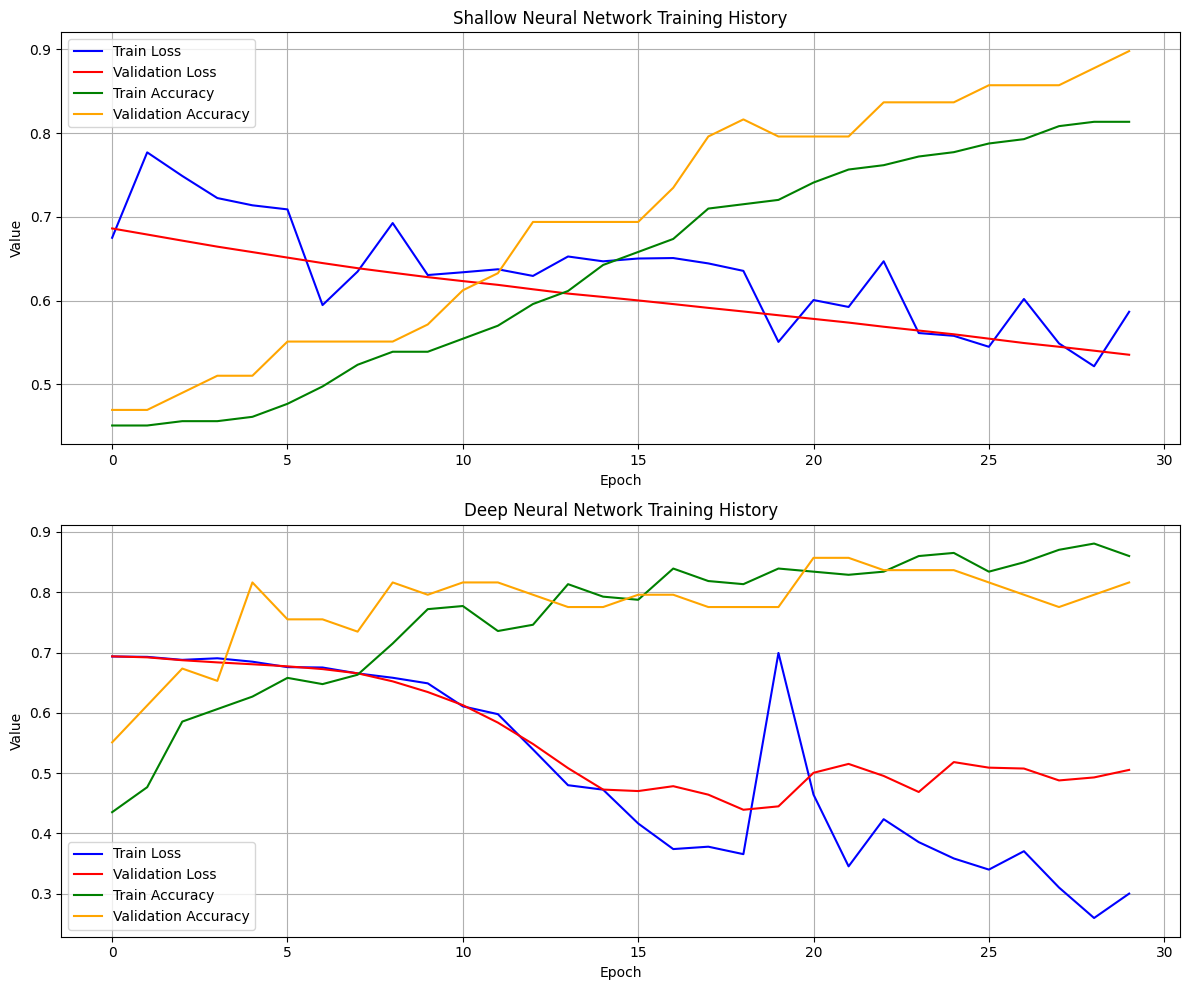

In [190]:
# Training History (2×1 Matrix)

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# SHALLOW
axes[0].plot(best_history["train_loss"], label="Train Loss", color="blue")
axes[0].plot(best_history["val_loss"], label="Validation Loss", color="red")
axes[0].plot(best_history["train_acc"], label="Train Accuracy", color="green")
axes[0].plot(best_history["val_acc"], label="Validation Accuracy", color="orange")

axes[0].set_title("Shallow Neural Network Training History")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Value")
axes[0].grid(True)
axes[0].legend()

#  DEEP
axes[1].plot(best_deep_history["train_loss"], label="Train Loss", color="blue")
axes[1].plot(best_deep_history["val_loss"], label="Validation Loss", color="red")
axes[1].plot(best_deep_history["train_acc"], label="Train Accuracy", color="green")
axes[1].plot(best_deep_history["val_acc"], label="Validation Accuracy", color="orange")

axes[1].set_title("Deep Neural Network Training History")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Value")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

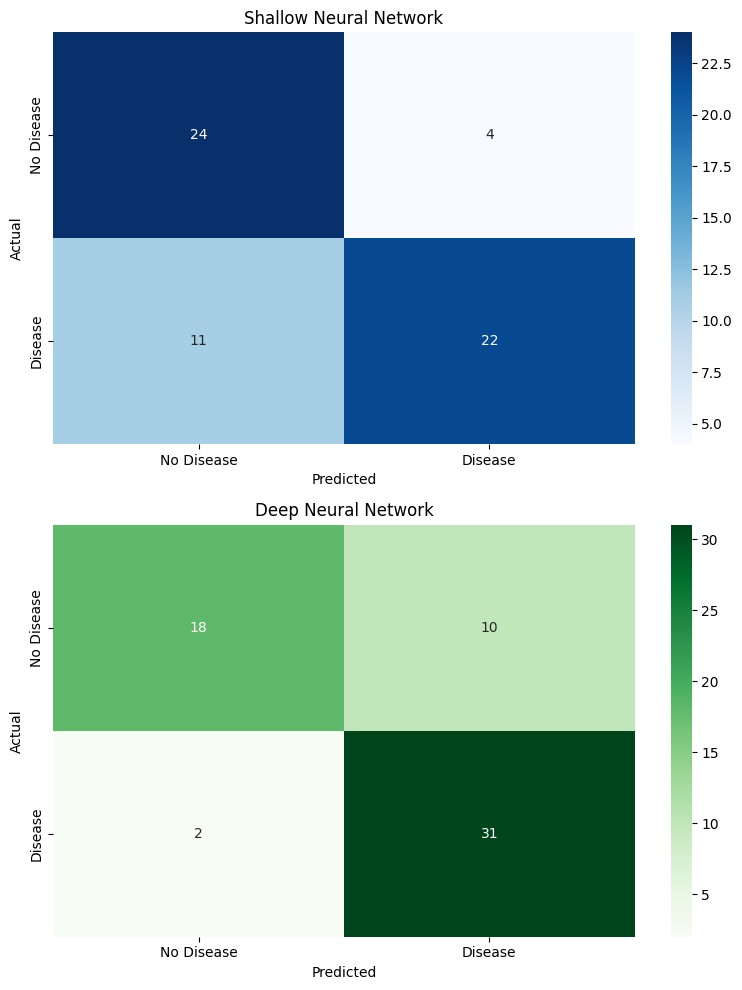

In [191]:
# Confusion Matrix (2×1 Matrix)

fig, axes = plt.subplots(2,1, figsize=(8,10))

cm_shallow = confusion_matrix(y_test, shallow_preds)

sns.heatmap(
    cm_shallow,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Disease','Disease'],
    yticklabels=['No Disease','Disease'],
    ax=axes[0]
)

axes[0].set_title("Shallow Neural Network")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")


cm_deep = confusion_matrix(y_test, deep_preds)

sns.heatmap(
    cm_deep,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['No Disease','Disease'],
    yticklabels=['No Disease','Disease'],
    ax=axes[1]
)

axes[1].set_title("Deep Neural Network")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

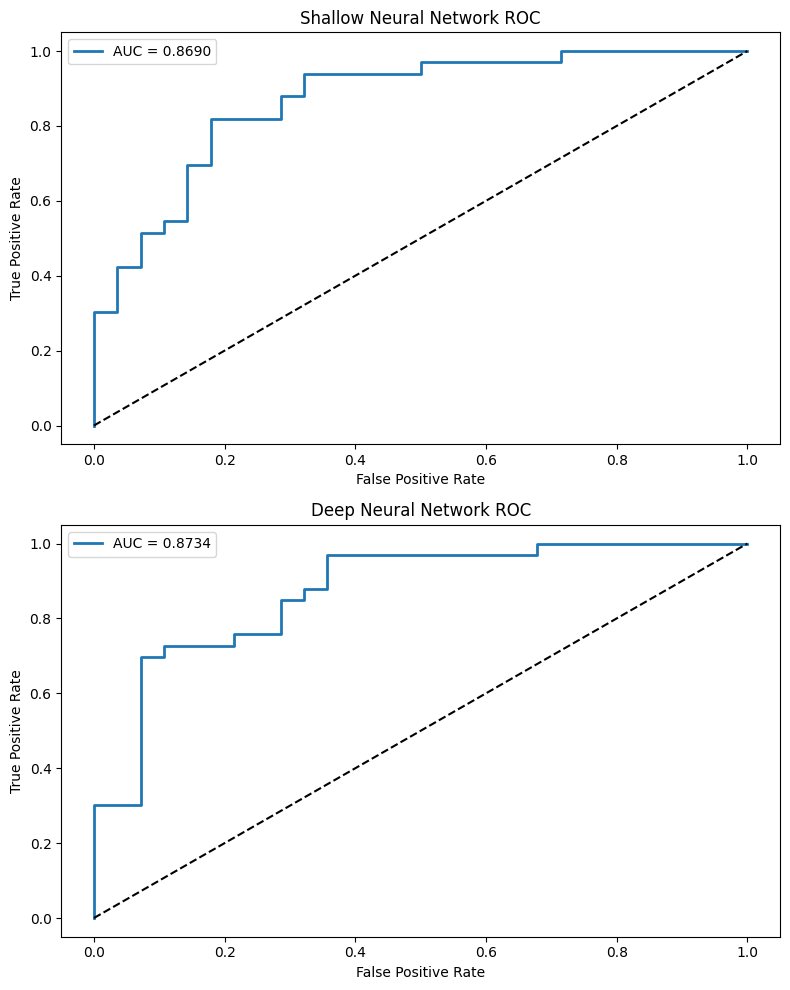

Shallow Model AUC : 0.8690
Deep Model AUC    : 0.8734


In [192]:
# ROC Curve (2×1 Matrix)

fig, axes = plt.subplots(2,1, figsize=(8,10))

# Shallow
fpr1, tpr1, _ = roc_curve(y_test, shallow_probs)
auc1 = roc_auc_score(y_test, shallow_probs)

axes[0].plot(fpr1, tpr1, linewidth=2,
             label=f"AUC = {auc1:.4f}")

axes[0].plot([0,1],[0,1],'k--')

axes[0].set_title("Shallow Neural Network ROC")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()

# Deep
fpr2, tpr2, _ = roc_curve(y_test, deep_probs)
auc2 = roc_auc_score(y_test, deep_probs)

axes[1].plot(fpr2, tpr2, linewidth=2,
             label=f"AUC = {auc2:.4f}")

axes[1].plot([0,1],[0,1],'k--')

axes[1].set_title("Deep Neural Network ROC")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend()

plt.tight_layout()
plt.show()

print("="*50)
print(f"Shallow Model AUC : {auc1:.4f}")
print(f"Deep Model AUC    : {auc2:.4f}")
print("="*50)

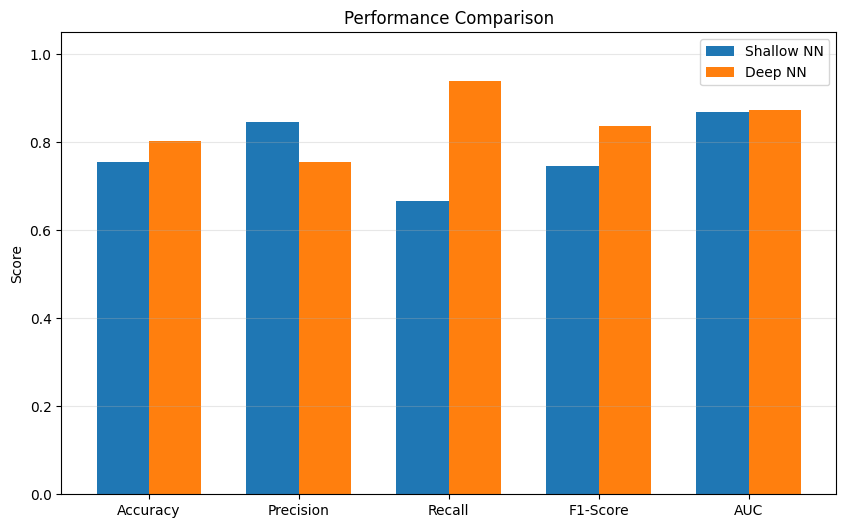

In [193]:
# Grouped Bar Chart

metrics = ["Accuracy","Precision","Recall","F1-Score","AUC"]

shallow_scores = [
    shallow_results["Accuracy"],
    shallow_results["Precision"],
    shallow_results["Recall"],
    shallow_results["F1"],
    shallow_results["AUC"]
]

deep_scores = [
    deep_results["Accuracy"],
    deep_results["Precision"],
    deep_results["Recall"],
    deep_results["F1"],
    deep_results["AUC"]
]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10,6))

plt.bar(x-width/2,
        shallow_scores,
        width,
        label="Shallow NN")

plt.bar(x+width/2,
        deep_scores,
        width,
        label="Deep NN")

plt.xticks(x, metrics)

plt.ylabel("Score")
plt.ylim(0,1.05)

plt.title("Performance Comparison")

plt.legend()

plt.grid(axis='y', alpha=0.3)

plt.show()

In [194]:
# Network Structure

print("="*70)
print("SHALLOW NEURAL NETWORK")
print("="*70)

print(best_model)

print()

print("Layer Summary")

for i, layer in enumerate(best_model.network):
    print(f"Layer {i+1}: {layer}")

print()

print("Total Parameters:",
      sum(p.numel() for p in best_model.parameters()))

print("\n\n")

print("="*70)
print("DEEP NEURAL NETWORK")
print("="*70)

print(best_deep_model)

print()

print("Layer Summary")

for i, layer in enumerate(best_deep_model.network):
    print(f"Layer {i+1}: {layer}")

print()

print("Total Parameters:",
      sum(p.numel() for p in best_deep_model.parameters()))

SHALLOW NEURAL NETWORK
ShallowNN(
  (network): Sequential(
    (0): Linear(in_features=13, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=1, bias=True)
  )
)

Layer Summary
Layer 1: Linear(in_features=13, out_features=16, bias=True)
Layer 2: ReLU()
Layer 3: Linear(in_features=16, out_features=1, bias=True)

Total Parameters: 241



DEEP NEURAL NETWORK
DeepNN(
  (network): Sequential(
    (0): Linear(in_features=13, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=32, out_features=1, bias=True)
  )
)

Layer Summary
Layer 1: Linear(in_features=13, out_features=128, bias=True)
Layer 2: ReLU()
Layer 3: Dropout(p=0.3, inplace=False)
Layer 4: Linear(in_features=

In [195]:
# Final Results Table

comparison = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "AUC"
    ],

    "Shallow":[
        shallow_results["Accuracy"],
        shallow_results["Precision"],
        shallow_results["Recall"],
        shallow_results["F1"],
        shallow_results["AUC"]
    ],

    "Deep":[
        deep_results["Accuracy"],
        deep_results["Precision"],
        deep_results["Recall"],
        deep_results["F1"],
        deep_results["AUC"]
    ]

})

comparison

,Metric,Shallow,Deep
0,Accuracy,0.754098,0.803279
1,Precision,0.846154,0.756098
2,Recall,0.666667,0.939394
3,F1 Score,0.745763,0.837838
4,AUC,0.869048,0.873377
